💡 **Environment:** `clamp-analyses`

# Description

Paired bootstrap significance test on the cross-method performance differences across the full grid of four methods — single-gene baseline (`gene_based`, NB06), ARCHS4 (`module_based_archs4`, NB07), GTEx (`module_based_gtex`, NB08), and recount2 (`module_based_recount2`, NB09) — for **all 6 pairwise comparisons**.

All methods are scored on an **identical** set of (drug, disease) pairs (produced by `00_aggregate_predictions.ipynb`). Each bootstrap iteration draws **one** resample of pairs and recomputes *every* method's metric on it; the per-comparison difference is then `metric_b − metric_a` from those shared-resample arrays. Reusing the same resample for every method (and every comparison) is what makes the difference test paired and the comparisons mutually consistent. We report a 95% CI and a bootstrap p-value on each difference, in AUROC and AUPRC.

The results table is one row per (comparison, metric); Benjamini–Hochberg is applied **within each metric family** (6 AUROC comparisons together, 6 AUPRC separately).

**Sign convention:** for a comparison `(A, B)` taken in `METHOD_ORDER`, `diff = B − A` (the later method minus the earlier). `gene_based` is first, so gene-vs-module rows read "module − gene" (> 0 ⇒ the module model beats the single-gene baseline).

# Modules loading

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
from IPython.display import display

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score

from pyprojroot import here

# Settings

In [3]:
import itertools

SEED = 42
N_BOOT = 10000

# All four methods, in a fixed order. The diff sign convention for a comparison
# (A, B) is diff = B - A (the later method in METHOD_ORDER minus the earlier).
# gene_based is first, so gene-vs-module comparisons read "module - gene"
# (> 0 means the module model beats the single-gene baseline).
METHOD_ORDER = [
    'gene_based',
    'module_based_archs4',
    'module_based_gtex',
    'module_based_recount2',
]
COMPARISONS = list(itertools.combinations(METHOD_ORDER, 2))  # 6 pairwise

METRICS = {
    'AUROC': roc_auc_score,
    'AUPRC': average_precision_score,
}

OUTPUT_DIR = here(
    'output/03_model_biology/00_archs4/02_drug_disease_associations/14_signif_test')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
display(OUTPUT_DIR)
display(COMPARISONS)

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/signif_test')

[('gene_based', 'module_based_archs4'),
 ('gene_based', 'module_based_gtex'),
 ('gene_based', 'module_based_recount2'),
 ('module_based_archs4', 'module_based_gtex'),
 ('module_based_archs4', 'module_based_recount2'),
 ('module_based_gtex', 'module_based_recount2')]

# Load paired predictions

In [4]:
predictions_avg = pd.read_pickle(OUTPUT_DIR / 'predictions_paired.pkl')
display(predictions_avg.shape)
display(predictions_avg.head())
display(predictions_avg['method'].value_counts())

(2740, 5)

,trait,drug,method,score,true_class
0,DOID:0050741,DB00215,gene_based,316134.3,1.0
1,DOID:0050741,DB00215,module_based_archs4,324870.1,1.0
2,DOID:0050741,DB00215,module_based_gtex,349350.5,1.0
3,DOID:0050741,DB00215,module_based_recount2,398655.9,1.0
4,DOID:0050741,DB00704,gene_based,387103.6,1.0


method
gene_based               685
module_based_archs4      685
module_based_gtex        685
module_based_recount2    685
Name: count, dtype: int64

# Pivot to wide (one row per pair, one score column per method)

The shared `(trait, drug)` index across methods *is* the pairing used by the bootstrap.

In [5]:
wide_score = predictions_avg.pivot_table(
    index=['trait', 'drug'], columns='method', values='score', observed=True)
wide_label = (
    predictions_avg.groupby(['trait', 'drug'], observed=True)['true_class']
    .agg(lambda s: s.unique()[0]))

# Every method must be defined on exactly the same (trait, drug) pairs (no NaNs).
# This shared index *is* the pairing the bootstrap relies on.
missing = [m for m in METHOD_ORDER if m not in wide_score.columns]
assert not missing, (
    f'methods absent from predictions_paired.pkl: {missing} -- re-run NB00 '
    f'(it aggregates all of NB06-NB09)')
assert wide_score[METHOD_ORDER].notna().all().all(), 'methods differ in pair coverage'

wide_score = wide_score.loc[wide_label.index]
y_true = wide_label.values.astype(int)
scores = {m: wide_score[m].values for m in METHOD_ORDER}
n = len(y_true)
display(f'{n} paired (drug, disease) pairs; '
        f'positives={int(y_true.sum())}, negatives={int((y_true == 0).sum())}')

'685 paired (drug, disease) pairs; positives=531, negatives=154'

# Observed metrics

In [6]:
# Observed (point-estimate) metric per method.
observed = {
    mname: {m: mfunc(y_true, scores[m]) for m in METHOD_ORDER}
    for mname, mfunc in METRICS.items()
}
display(pd.DataFrame(observed))

# Sanity vs NB10 published AUROC.
_NB10_AUROC = {
    'gene_based': 0.583, 'module_based_archs4': 0.625,
    'module_based_gtex': 0.602, 'module_based_recount2': 0.612,
}
for m in METHOD_ORDER:
    ref = _NB10_AUROC.get(m, float('nan'))
    print(f"AUROC {m}={observed['AUROC'][m]:.3f} (NB10 ~{ref:.3f})")

,AUROC,AUPRC
gene_based,0.583382,0.844942
module_based_archs4,0.625419,0.849646
module_based_gtex,0.602484,0.839313
module_based_recount2,0.612267,0.845789


AUROC gene_based=0.583 (NB10 ~0.583)
AUROC module_based_archs4=0.625 (NB10 ~0.625)
AUROC module_based_gtex=0.602 (NB10 ~0.602)
AUROC module_based_recount2=0.612 (NB10 ~0.612)


# Paired bootstrap

In [7]:
np.random.seed(SEED)

# Bootstrap each method's metric ONCE per resample, reusing the SAME resample
# indices across every method (and therefore every comparison). Pairwise diffs
# are derived by subtraction afterward, which is valid because the per-method
# arrays are aligned iteration-by-iteration to the same resample. This is both
# the paired-test requirement and ~3x cheaper than re-looping per comparison
# (4 metric evals/iter instead of 6 pair x 2 method evals).
boot_metric = {mname: {m: [] for m in METHOD_ORDER} for mname in METRICS}
n_skipped = 0

for _ in range(N_BOOT):
    idx = np.random.choice(n, n, replace=True)   # same resample for every method
    yb = y_true[idx]
    if len(np.unique(yb)) < 2:                    # AUROC/AUPRC undefined; skip whole iter
        n_skipped += 1
        continue
    for mname, mfunc in METRICS.items():
        for m in METHOD_ORDER:
            boot_metric[mname][m].append(mfunc(yb, scores[m][idx]))

boot_metric = {
    mname: {m: np.asarray(v) for m, v in d.items()}
    for mname, d in boot_metric.items()
}
display(f'Bootstrap iterations used: {N_BOOT - n_skipped} '
        f'(skipped {n_skipped} single-class resamples)')

'Bootstrap iterations used: 10000 (skipped 0 single-class resamples)'

# Results: CI + bootstrap p-value on the difference

In [8]:
def boot_ci(arr, lo=2.5, hi=97.5):
    return np.percentile(arr, lo), np.percentile(arr, hi)


def boot_pvalue_two_sided(diffs):
    """Two-sided bootstrap p-value for H0: diff == 0.

    Uses the (count + 1) / (N + 1) convention (Davison & Hinkley 1997) so the
    p-value is never exactly 0 -- it is floored at 2 / (N + 1). The naive
    2 * min(tail proportion) can read 0.0 when no resample crosses zero, which
    overstates significance in a publication table.
    """
    n = len(diffs)
    p_le = ((diffs <= 0).sum() + 1) / (n + 1)
    p_ge = ((diffs >= 0).sum() + 1) / (n + 1)
    return min(2.0 * min(p_le, p_ge), 1.0)


# One row per (metric, comparison). Column names are metric-agnostic (a_* / b_*
# refer to method_a / method_b, whose metric is named in the `metric` column).
rows = []
for mname in METRICS:
    for method_a, method_b in COMPARISONS:
        boot_a = boot_metric[mname][method_a]
        boot_b = boot_metric[mname][method_b]
        boot_diff = boot_b - boot_a            # paired: same resample per iteration
        a_lo, a_hi = boot_ci(boot_a)
        b_lo, b_hi = boot_ci(boot_b)
        diff_lo, diff_hi = boot_ci(boot_diff)
        rows.append({
            'metric': mname,
            'comparison': f'{method_b} vs {method_a}',
            'method_a': method_a,
            'method_b': method_b,
            'a_obs': observed[mname][method_a], 'a_lo': a_lo, 'a_hi': a_hi,
            'b_obs': observed[mname][method_b], 'b_lo': b_lo, 'b_hi': b_hi,
            'diff_obs': observed[mname][method_b] - observed[mname][method_a],
            'diff_boot_mean': boot_diff.mean(),
            'diff_ci_lo': diff_lo, 'diff_ci_hi': diff_hi,
            'ci_excludes_0': bool(diff_lo > 0 or diff_hi < 0),
            'p_value': boot_pvalue_two_sided(boot_diff),
        })

results = pd.DataFrame(rows)
display(f'{len(results)} comparison-metric rows '
        f'({len(COMPARISONS)} pairs x {len(METRICS)} metrics)')

'12 comparison-metric rows (6 pairs x 2 metrics)'

In [9]:
def bh_correct(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = ranked * m / (np.arange(m) + 1)
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    out = np.empty(m)
    out[order] = np.minimum(adj, 1.0)
    return out

# Benjamini-Hochberg WITHIN each metric family: the 6 AUROC comparisons are
# corrected together, the 6 AUPRC comparisons separately. AUROC and AUPRC are
# distinct hypothesis families, so pooling them into one correction set would
# not be coherent.
results['p_value_bh'] = (
    results.groupby('metric', sort=False)['p_value'].transform(bh_correct))

# Headline AUROC comparisons, sorted by corrected p-value.
display(
    results[results['metric'] == 'AUROC']
    .sort_values('p_value_bh')
    [['comparison', 'a_obs', 'b_obs', 'diff_obs',
      'diff_ci_lo', 'diff_ci_hi', 'ci_excludes_0', 'p_value', 'p_value_bh']]
    .reset_index(drop=True))
display(results)

,comparison,a_obs,b_obs,diff_obs,diff_ci_lo,diff_ci_hi,ci_excludes_0,p_value,p_value_bh
0,module_based_archs4 vs gene_based,0.583382,0.625419,0.042037,-0.000199,0.084255,False,0.052195,0.313169
1,module_based_recount2 vs gene_based,0.583382,0.612267,0.028884,-0.019236,0.075399,False,0.236776,0.473553
2,module_based_gtex vs module_based_archs4,0.625419,0.602484,-0.022935,-0.059730,0.012957,False,0.209179,0.473553
3,module_based_gtex vs gene_based,0.583382,0.602484,0.019101,-0.026174,0.063285,False,0.399360,0.599040
4,module_based_recount2 vs module_based_archs4,0.625419,0.612267,-0.013152,-0.053987,0.027764,False,0.524148,0.608939
5,module_based_recount2 vs module_based_gtex,0.602484,0.612267,0.009783,-0.027521,0.047957,False,0.608939,0.608939


,metric,comparison,method_a,method_b,a_obs,a_lo,a_hi,b_obs,b_lo,b_hi,diff_obs,diff_boot_mean,diff_ci_lo,diff_ci_hi,ci_excludes_0,p_value,p_value_bh
0,AUROC,module_based_archs4 vs gene_based,gene_based,module_based_archs4,0.583382,0.537457,0.630536,0.625419,0.577098,0.673901,0.042037,0.041802,-0.000199,0.084255,False,0.052195,0.313169
1,AUROC,module_based_gtex vs gene_based,gene_based,module_based_gtex,0.583382,0.537457,0.630536,0.602484,0.554105,0.648990,0.019101,0.018866,-0.026174,0.063285,False,0.399360,0.599040
2,AUROC,module_based_recount2 vs gene_based,gene_based,module_based_recount2,0.583382,0.537457,0.630536,0.612267,0.563919,0.660713,0.028884,0.028870,-0.019236,0.075399,False,0.236776,0.473553
3,AUROC,module_based_gtex vs module_based_archs4,module_based_archs4,module_based_gtex,0.625419,0.577098,0.673901,0.602484,0.554105,0.648990,-0.022935,-0.022936,-0.059730,0.012957,False,0.209179,0.473553
4,AUROC,module_based_recount2 vs module_based_archs4,module_based_archs4,module_based_recount2,0.625419,0.577098,0.673901,0.612267,0.563919,0.660713,-0.013152,-0.012932,-0.053987,0.027764,False,0.524148,0.608939
5,AUROC,module_based_recount2 vs module_based_gtex,module_based_gtex,module_based_recount2,0.602484,0.554105,0.648990,0.612267,0.563919,0.660713,0.009783,0.010004,-0.027521,0.047957,False,0.608939,0.608939
6,AUPRC,module_based_archs4 vs gene_based,gene_based,module_based_archs4,0.844942,0.812530,0.876544,0.849646,0.814751,0.883852,0.004705,0.004823,-0.016558,0.025472,False,0.650335,0.784002
7,AUPRC,module_based_gtex vs gene_based,gene_based,module_based_gtex,0.844942,0.812530,0.876544,0.839313,0.802782,0.875004,-0.005628,-0.005356,-0.028267,0.016630,False,0.653335,0.784002
8,AUPRC,module_based_recount2 vs gene_based,gene_based,module_based_recount2,0.844942,0.812530,0.876544,0.845789,0.810633,0.880021,0.000847,0.000975,-0.020445,0.022108,False,0.912909,0.912909
9,AUPRC,module_based_gtex vs module_based_archs4,module_based_archs4,module_based_gtex,0.849646,0.814751,0.883852,0.839313,0.802782,0.875004,-0.010333,-0.010180,-0.025273,0.004423,False,0.169383,0.784002


In [10]:
out_csv = OUTPUT_DIR / 'paired_bootstrap_results.csv'
out_pkl = OUTPUT_DIR / 'paired_bootstrap_results.pkl'
results.to_csv(out_csv, index=False)
results.to_pickle(out_pkl)
display(out_csv)

PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/signif_test/paired_bootstrap_results.csv')

# Plot: forest plot of pairwise metric differences

One panel per metric; one row per pairwise comparison showing the observed difference (`metric_b − metric_a`) with its 95% bootstrap CI. The dashed line marks no difference (0). A CI that **excludes 0** (red) is significant at α=0.05; a CI crossing 0 (grey) is not.

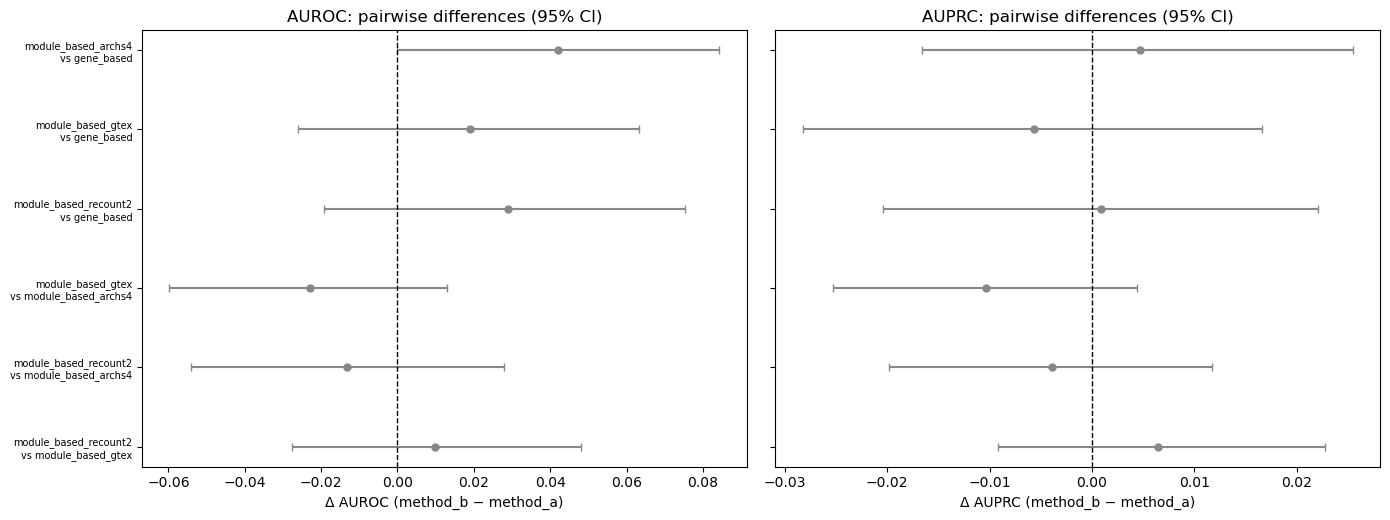

In [11]:
# Forest plot: observed difference + 95% CI, one panel per metric, one row per
# pairwise comparison. Red = CI excludes 0 (significant); grey = CI crosses 0.
fig, axes = plt.subplots(
    1, len(METRICS),
    figsize=(7 * len(METRICS), 0.55 * len(COMPARISONS) + 2),
    sharey=True)
if len(METRICS) == 1:
    axes = [axes]

for ax, mname in zip(axes, METRICS):
    sub = results[results['metric'] == mname].reset_index(drop=True)
    ypos = np.arange(len(sub))[::-1]   # first comparison at the top
    for y, (_, r) in zip(ypos, sub.iterrows()):
        color = '#C44E52' if r['ci_excludes_0'] else '#888888'
        ax.errorbar(
            r['diff_obs'], y,
            xerr=[[r['diff_obs'] - r['diff_ci_lo']],
                  [r['diff_ci_hi'] - r['diff_obs']]],
            fmt='o', color=color, ecolor=color, capsize=3, markersize=5)
    ax.axvline(0, color='black', linestyle='--', linewidth=1)
    ax.set_yticks(ypos)
    ax.set_yticklabels(
        [f"{r['method_b']}\nvs {r['method_a']}" for _, r in sub.iterrows()],
        fontsize=7)
    ax.set_xlabel(f'Δ {mname} (method_b − method_a)')
    ax.set_title(f'{mname}: pairwise differences (95% CI)')

fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'paired_bootstrap_diff.png', dpi=150, bbox_inches='tight')
plt.show()

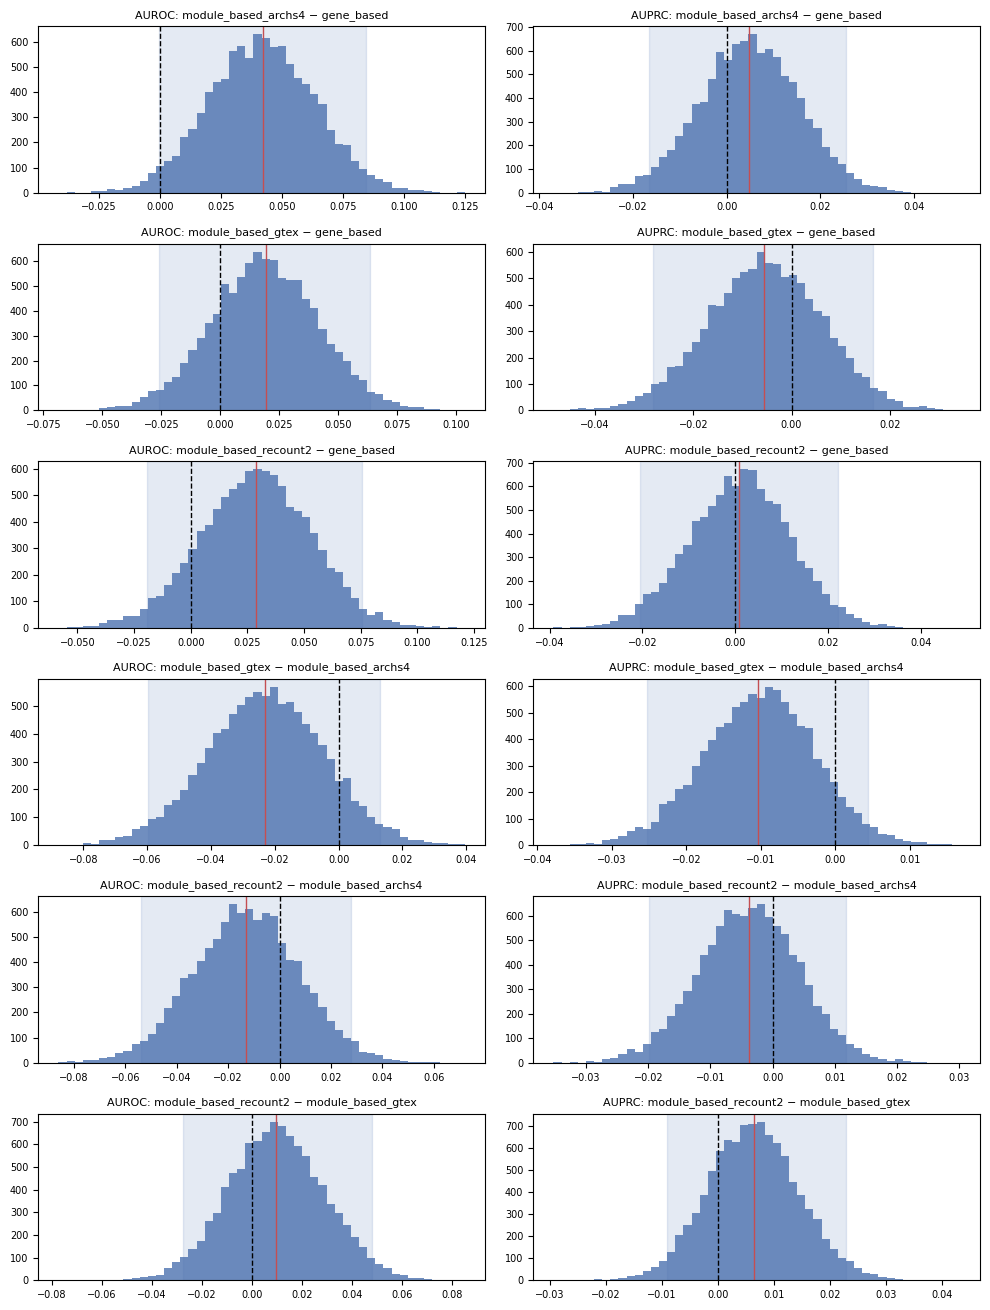

In [12]:
# Appendix: per-pair bootstrap difference distributions (rows = comparisons,
# cols = metrics). Same information as the forest plot, full distribution shown.
fig, axes = plt.subplots(
    len(COMPARISONS), len(METRICS),
    figsize=(5 * len(METRICS), 2.2 * len(COMPARISONS)),
    squeeze=False)
for i, (method_a, method_b) in enumerate(COMPARISONS):
    for j, mname in enumerate(METRICS):
        ax = axes[i][j]
        d = boot_metric[mname][method_b] - boot_metric[mname][method_a]
        lo, hi = np.percentile(d, [2.5, 97.5])
        obs = observed[mname][method_b] - observed[mname][method_a]
        ax.hist(d, bins=50, color='#4C72B0', alpha=0.8)
        ax.axvline(0, color='black', linestyle='--', linewidth=1)
        ax.axvline(obs, color='#C44E52', linestyle='-', linewidth=1)
        ax.axvspan(lo, hi, color='#4C72B0', alpha=0.15)
        ax.set_title(f'{mname}: {method_b} − {method_a}', fontsize=8)
        ax.tick_params(labelsize=7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'paired_bootstrap_hist.png', dpi=150, bbox_inches='tight')
plt.show()

# Ordering-stability (beyond p-values)

The paired test above finds **no** pairwise AUROC difference significant at α=0.05. Here we characterize, *without* dichotomizing on a p-value, two patterns visible in the effect sizes: (1) all three LV methods beat the gene baseline directionally, and (2) AUROC is ordered by model size (ARCHS4 > recount2 > GTEx > gene). We reuse the per-resample metric arrays from the paired bootstrap (`boot_metric`, aligned across methods iteration-by-iteration — **no re-bootstrapping**) to compute:

- **Pairwise dominance probabilities** `P(metric_A > metric_B)` across resamples (a threshold-free complement to the two-sided p-values above).
- **Ordering-preservation fractions**: fraction of resamples where the size-ordered chain holds (4-method `archs4>recount2>gtex>gene` and LV-only `archs4>recount2>gtex`), the adjacent-pair links, and the "all three LV > gene simultaneously" fraction.
- **Spearman(model size, AUROC)** per resample → observed value, bootstrap mean, 95% CI, fraction == 1.0 (perfect concordance), fraction > 0.

**Guardrails — this is descriptive / hypothesis-generating, not confirmatory:**
- The three models share the same gold-standard pairs and the same S-PrediXcan / LINCS input signatures, so this is **correlated** corroboration, *not* three independent replications.
- "Size" is confounded with dataset diversity/heterogeneity and with latent dimensionality (LV count is not fixed across models).
- n=3 models is weak for a trend (a random ordering matches by chance with p≈1/6). A definitive test would be a within-dataset size gradient (subsample ARCHS4).

In [13]:
from scipy.stats import spearmanr

# Model-size order (descending): ARCHS4 largest, then recount2, then GTEx;
# gene_based is the floor. Hypothesis under test: AUROC tracks this order.
SIZE_ORDER = ['module_based_archs4', 'module_based_recount2',
              'module_based_gtex', 'gene_based']
LV_SIZE_ORDER = SIZE_ORDER[:3]          # clean size gradient among LV models only
SIZE_SCORE = np.array([4, 3, 2, 1])     # larger = bigger model, aligned to SIZE_ORDER


def dominance_matrix(boot):
    """P(metric_row > metric_col) across resamples; rows/cols follow boot's keys."""
    ms = list(boot.keys())
    return pd.DataFrame(
        [[float(np.mean(boot[a] > boot[b])) for b in ms] for a in ms],
        index=ms, columns=ms)


def ordering_fraction(boot, order):
    """Fraction of resamples where boot[order[0]] > boot[order[1]] > ..."""
    arrs = [boot[m] for m in order]
    holds = np.ones(len(arrs[0]), dtype=bool)
    for x, y in zip(arrs[:-1], arrs[1:]):
        holds &= (x > y)
    return float(holds.mean())


# All statistics reuse `boot_metric` (per-method arrays aligned across methods
# iteration-by-iteration -- the same property the paired difference test relies
# on). No re-bootstrapping. AUROC is the headline; AUPRC is carried along.
rows = []
dominance = {}
for mname in METRICS:
    boot = {m: boot_metric[mname][m] for m in SIZE_ORDER}

    # (1) Pairwise dominance probabilities P(row > col).
    dom = dominance_matrix(boot)
    dominance[mname] = dom
    for a in SIZE_ORDER:
        for b in SIZE_ORDER:
            if a == b:
                continue
            rows.append(dict(metric=mname, category='dominance',
                             key=f'P({a}>{b})', value=dom.loc[a, b]))

    # (2) Ordering-preservation fractions (full chain + LV-only).
    rows.append(dict(metric=mname, category='ordering',
                     key='full_4method[archs4>recount2>gtex>gene]',
                     value=ordering_fraction(boot, SIZE_ORDER)))
    rows.append(dict(metric=mname, category='ordering',
                     key='lv_only[archs4>recount2>gtex]',
                     value=ordering_fraction(boot, LV_SIZE_ORDER)))

    # All three LV methods above gene simultaneously (directional consistency).
    g = boot['gene_based']
    all_lv = np.ones(len(g), dtype=bool)
    for m in LV_SIZE_ORDER:
        all_lv &= (boot[m] > g)
    rows.append(dict(metric=mname, category='ordering',
                     key='all_LV>gene_simultaneously', value=float(all_lv.mean())))

    # Adjacent-pair decomposition of the full ordering (the chain's links).
    for a, b in zip(SIZE_ORDER[:-1], SIZE_ORDER[1:]):
        rows.append(dict(metric=mname, category='adjacent',
                         key=f'P({a}>{b})', value=dom.loc[a, b]))

    # (3) Spearman(model size, metric) per resample -> distribution.
    A = np.column_stack([boot[m] for m in SIZE_ORDER])
    rhos = np.array([spearmanr(SIZE_SCORE, row)[0] for row in A])
    obs_rho = spearmanr(SIZE_SCORE, [observed[mname][m] for m in SIZE_ORDER])[0]
    lo, hi = boot_ci(rhos)
    rows += [
        dict(metric=mname, category='spearman', key='observed_rho', value=obs_rho),
        dict(metric=mname, category='spearman', key='boot_mean_rho', value=float(rhos.mean())),
        dict(metric=mname, category='spearman', key='ci_lo', value=lo),
        dict(metric=mname, category='spearman', key='ci_hi', value=hi),
        dict(metric=mname, category='spearman', key='frac_rho==1', value=float((rhos == 1.0).mean())),
        dict(metric=mname, category='spearman', key='frac_rho>0', value=float((rhos > 0).mean())),
    ]

ordering_results = pd.DataFrame(rows)

# Headline AUROC views.
display('AUROC pairwise dominance P(row > col):')
display(dominance['AUROC'].round(3))
display('AUROC ordering / spearman summary:')
display(
    ordering_results[(ordering_results.metric == 'AUROC')
                     & ordering_results.category.isin(['ordering', 'spearman'])]
    [['key', 'value']].round(3).reset_index(drop=True))

'AUROC pairwise dominance P(row > col):'

,module_based_archs4,module_based_recount2,module_based_gtex,gene_based
module_based_archs4,0.000,0.738,0.896,0.974
module_based_recount2,0.262,0.000,0.696,0.882
module_based_gtex,0.104,0.304,0.000,0.800
gene_based,0.026,0.118,0.200,0.000


'AUROC ordering / spearman summary:'

,key,value
0,full_4method[archs4>recount2>gtex>gene],0.326
1,lv_only[archs4>recount2>gtex],0.452
2,all_LV>gene_simultaneously,0.753
3,observed_rho,1.000
4,boot_mean_rho,0.742
5,ci_lo,0.000
6,ci_hi,1.000
7,frac_rho==1,0.326
8,frac_rho>0,0.970


PosixPath('/home/miltondp/projects/clamp/clamp-analyses/output/03_model_biology/00_archs4/02_drug_disease_associations/signif_test/ordering_stability.csv')

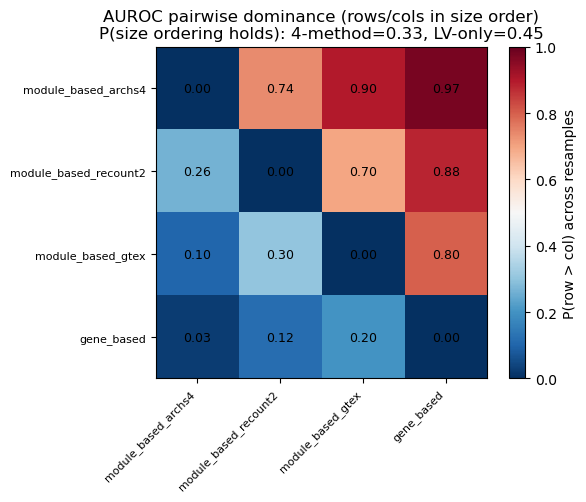

In [14]:
# Save and plot the AUROC dominance heatmap (rows/cols in size order).
out_csv = OUTPUT_DIR / 'ordering_stability.csv'
ordering_results.to_csv(out_csv, index=False)
display(out_csv)

mname = 'AUROC'
dom = dominance[mname]
boot = {m: boot_metric[mname][m] for m in SIZE_ORDER}
full_frac = ordering_fraction(boot, SIZE_ORDER)
lv_frac = ordering_fraction(boot, LV_SIZE_ORDER)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(dom.values, vmin=0, vmax=1, cmap='RdBu_r')
ax.set_xticks(range(len(SIZE_ORDER)))
ax.set_xticklabels(SIZE_ORDER, rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(SIZE_ORDER)))
ax.set_yticklabels(SIZE_ORDER, fontsize=8)
for i in range(len(SIZE_ORDER)):
    for j in range(len(SIZE_ORDER)):
        ax.text(j, i, f'{dom.values[i, j]:.2f}', ha='center', va='center',
                fontsize=9, color='black')
fig.colorbar(im, ax=ax, label='P(row > col) across resamples')
ax.set_title('AUROC pairwise dominance (rows/cols in size order)\n'
             f'P(size ordering holds): 4-method={full_frac:.2f}, '
             f'LV-only={lv_frac:.2f}')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'ordering_stability.png', dpi=150, bbox_inches='tight')
plt.show()